# Teaching File: embeddings + búsqueda por similitud sobre ROCOv2

Prueba de concepto en Google Colab. Pipeline:
1. Cargar el dataset **ROCOv2-radiology** (imagen + caption + conceptos UMLS).
2. Generar embeddings con encoders open-source intercambiables (`resnet50`, `dinov2`, `biomedclip`).
3. Indexar y buscar por similitud coseno: **imagen → imagen** y, con BiomedCLIP, **texto → imagen**.

**Antes de empezar:** activa GPU en `Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU (T4)`.

In [1]:
# === 1. Instalación ===
# torch, torchvision y matplotlib ya vienen en Colab. timm es requerido por
# el image tower de BiomedCLIP; faiss-cpu es opcional (escala la búsqueda).
!pip install -q open_clip_torch timm datasets faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 112.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


In [2]:
# === 2. Imports, reproducibilidad y dispositivo ===
import os, random, itertools
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

Dispositivo: cuda


## 3. Cargar ROCOv2

El split completo (~79k imágenes) pesa decenas de GB. Para una PoC conviene:
- `mini`: muestra de 2.305 filas (rápido, ideal para depurar el pipeline).
- `stream_full`: hace *streaming* del dataset real y toma solo las primeras `N` (recomendado).
- `full_subset`: descarga todo el split y toma `N` (lento; úsalo solo si vas a reusar la descarga).

In [3]:
# === 3. Cargar el dataset ===
from datasets import load_dataset

LOAD_MODE = "stream_full"   # "mini" | "stream_full" | "full_subset"
N = 2000                     # nº de imágenes para la PoC (sube cuando esté afinado)

if LOAD_MODE == "mini":
    ds = load_dataset("unsloth/Radiology_mini", split="train")
    data = [ds[i] for i in range(min(N, len(ds)))]
elif LOAD_MODE == "stream_full":
    st = load_dataset("eltorio/ROCOv2-radiology", split="train", streaming=True)
    data = list(itertools.islice(st, N))
else:  # full_subset
    ds = load_dataset("eltorio/ROCOv2-radiology", split="train")
    data = [ds[i] for i in range(min(N, len(ds)))]

# Columnas alineadas por índice (sin volver a decodificar las imágenes).
captions = [r.get("caption", "") for r in data]
ids      = [r.get("image_id", str(i)) for i, r in enumerate(data)]
cuis     = [r.get("cui", []) for r in data]

print(f"Cargadas {len(data)} imágenes  |  modo={LOAD_MODE}")
ej = data[0]
print("campos:", list(ej.keys()))
print("image:", ej["image"], "| modo:", ej["image"].mode)
print("image_id:", ids[0])
print("caption:", captions[0][:160])
print("cui (UMLS):", cuis[0])

README.md:   0%|          | 0.00/4.50k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Cargadas 2000 imágenes  |  modo=stream_full
campos: ['image', 'image_id', 'caption', 'cui']
image: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=682x748 at 0x7FC20010B2F0> | modo: RGB
image_id: ROCOv2_2023_train_000001
caption: Head CT demonstrating left parotiditis.
cui (UMLS): ['C0040405']


## 4. Encoders intercambiables

Cada encoder expone `preprocess(pil)` y `encode_image_batch(batch)`. BiomedCLIP añade `encode_text(...)`
para búsqueda por texto. Agregar MedImageInsight o MedGemma luego es escribir una subclase más.

In [4]:
# === 4. Encoders ===
import torchvision
from torchvision import transforms
from torchvision.models import ResNet50_Weights

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

class BaseEncoder:
    embed_dim = None
    def __init__(self, device):
        self.device = device; self.model = None
    def preprocess(self, pil_img):
        raise NotImplementedError
    @torch.no_grad()
    def encode_image_batch(self, batch):
        raise NotImplementedError

class ResNetEncoder(BaseEncoder):
    """Línea base: ResNet50 (ImageNet)."""
    embed_dim = 2048
    def __init__(self, device):
        super().__init__(device)
        m = torchvision.models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        m.fc = torch.nn.Identity()
        self.model = m.eval().to(device)
        self.tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    def preprocess(self, pil_img):
        return self.tf(pil_img.convert("RGB"))
    @torch.no_grad()
    def encode_image_batch(self, batch):
        return self.model(batch.to(self.device)).float().cpu()

class DINOv2Encoder(BaseEncoder):
    """Generalista auto-supervisado (Meta, torch.hub)."""
    def __init__(self, device, variant="dinov2_vits14"):
        super().__init__(device)
        self.model = torch.hub.load("facebookresearch/dinov2", variant).eval().to(device)
        self.embed_dim = {"dinov2_vits14": 384, "dinov2_vitb14": 768, "dinov2_vitl14": 1024}[variant]
        self.tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    def preprocess(self, pil_img):
        return self.tf(pil_img.convert("RGB"))
    @torch.no_grad()
    def encode_image_batch(self, batch):
        return self.model(batch.to(self.device)).float().cpu()

class BiomedCLIPEncoder(BaseEncoder):
    """Específico de dominio médico (Microsoft, PMC-15M). Soporta texto->imagen."""
    embed_dim = 512
    def __init__(self, device):
        super().__init__(device)
        import open_clip
        name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
        self.model, self._preprocess = open_clip.create_model_from_pretrained(name)
        self.tokenizer = open_clip.get_tokenizer(name)
        self.model = self.model.eval().to(device)
    def preprocess(self, pil_img):
        return self._preprocess(pil_img.convert("RGB"))
    @torch.no_grad()
    def encode_image_batch(self, batch):
        return self.model.encode_image(batch.to(self.device)).float().cpu()
    @torch.no_grad()
    def encode_text(self, texts):
        tok = self.tokenizer(texts).to(self.device)
        return self.model.encode_text(tok).float().cpu()

ENCODERS = {"resnet50": ResNetEncoder, "dinov2": DINOv2Encoder, "biomedclip": BiomedCLIPEncoder}
def build_encoder(name, device):
    return ENCODERS[name](device)

In [5]:
# === 4b. Elegir y construir el encoder ===
ENCODER_NAME = "biomedclip"   # "resnet50" | "dinov2" | "biomedclip"
encoder = build_encoder(ENCODER_NAME, device)
print("encoder:", ENCODER_NAME, "| dim del embedding:", encoder.embed_dim)

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

encoder: biomedclip | dim del embedding: 512


## 5. Generar embeddings

Procesamos en lotes con un `DataLoader` (preprocesado por imagen en `__getitem__`) y
L2-normalizamos al final, de modo que el producto punto sea la similitud coseno.

In [6]:
# === 5. Embeddings ===
class HFImageDataset(Dataset):
    def __init__(self, rows, encoder):
        self.rows = rows; self.encoder = encoder
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        return self.encoder.preprocess(self.rows[i]["image"])

def generate_embeddings(rows, encoder, batch_size=64, num_workers=2, use_amp=True):
    loader = DataLoader(HFImageDataset(rows, encoder), batch_size=batch_size,
                        shuffle=False, num_workers=num_workers,
                        pin_memory=(encoder.device == "cuda"))
    embs = np.empty((len(rows), encoder.embed_dim), dtype=np.float32); pos = 0
    amp = use_amp and encoder.device == "cuda"
    for batch in loader:
        with torch.autocast("cuda", enabled=amp):
            e = encoder.encode_image_batch(batch)
        e = e.numpy().astype(np.float32); n = e.shape[0]
        embs[pos:pos + n] = e; pos += n
        print(f"  {pos}/{len(rows)}", end="\r")
    print()
    embs /= (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-12)   # L2
    return embs

emb = generate_embeddings(data, encoder, batch_size=64, num_workers=2)
np.save(f"emb_{ENCODER_NAME}.npy", emb)
print("embeddings:", emb.shape, "-> guardado en", f"emb_{ENCODER_NAME}.npy")

  2000/2000
embeddings: (2000, 512) -> guardado en emb_biomedclip.npy


## 6. Índice de similitud

Usa FAISS si está instalado (escala a cientos de miles / millones de vectores);
si no, cae a fuerza bruta con NumPy (perfecto para esta PoC).

In [7]:
# === 6. Índice ===
class SimilarityIndex:
    def __init__(self, embeddings):
        self.emb = embeddings.astype(np.float32); self.dim = embeddings.shape[1]
        self.backend = "numpy"; self._index = None
        try:
            import faiss
            self._index = faiss.IndexFlatIP(self.dim)   # IP == coseno si está L2-normalizado
            self._index.add(self.emb); self.backend = "faiss"
        except Exception:
            pass
    def search(self, q, k=5):
        if q.ndim == 1: q = q[None, :]
        q = q.astype(np.float32)
        if self.backend == "faiss":
            s, i = self._index.search(q, k); return i, s
        sims = q @ self.emb.T
        i = np.argsort(-sims, axis=1)[:, :k]
        s = np.take_along_axis(sims, i, axis=1); return i, s

index = SimilarityIndex(emb)
print("backend de búsqueda:", index.backend)

backend de búsqueda: faiss


## 7. Búsqueda imagen → imagen

Tomamos una imagen del repositorio como consulta y recuperamos las más parecidas, con su caption.

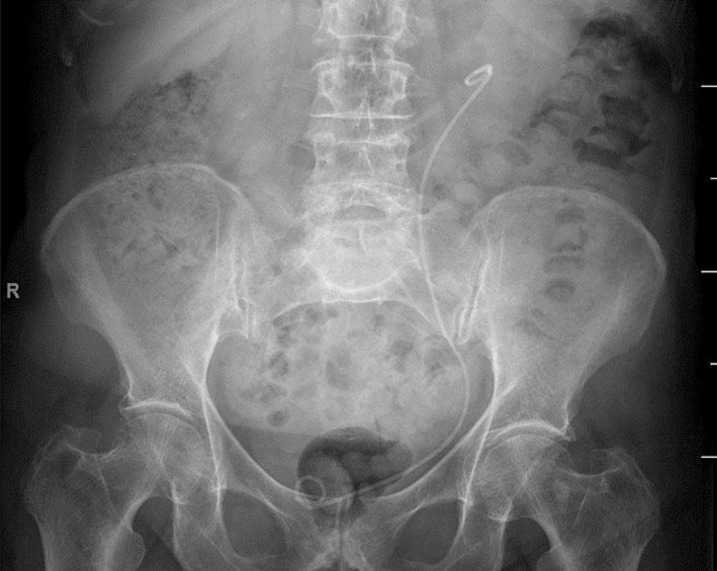

In [10]:
q = 115
data[q]["image"]

Consulta: The pigtail placed into the left kidney.


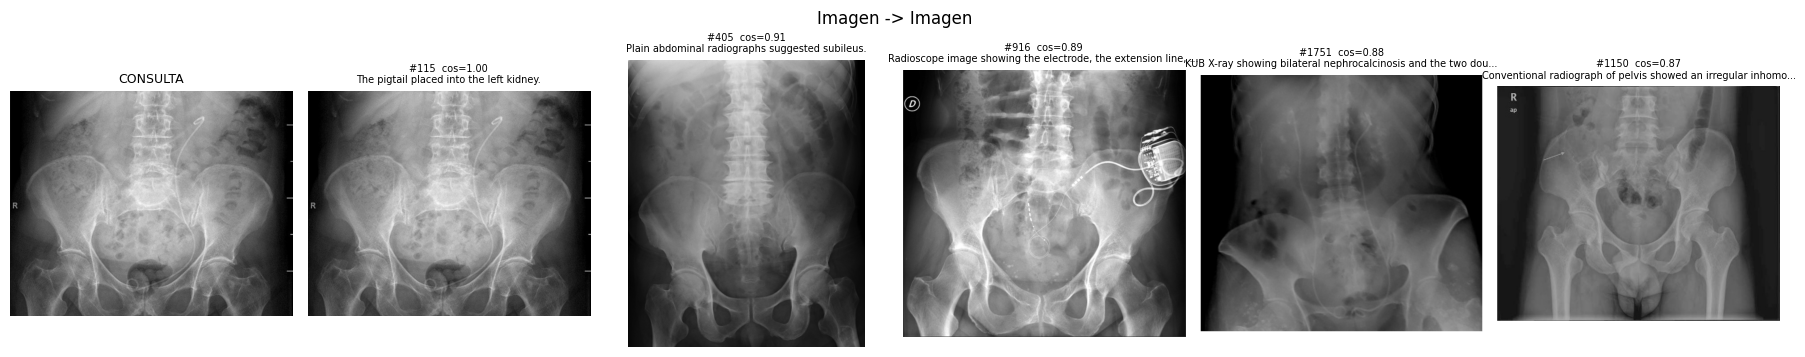

In [11]:
# === 7. Imagen -> imagen ===
import matplotlib.pyplot as plt

def _short(txt, n=60):
    return (txt[:n] + "...") if len(txt) > n else txt

def show_neighbors(neighbors, scores, query_img=None, title="Resultados"):
    k = len(neighbors); cols = k + (1 if query_img is not None else 0)
    fig, ax = plt.subplots(1, cols, figsize=(3 * cols, 3.6))
    if cols == 1: ax = [ax]
    off = 0
    if query_img is not None:
        ax[0].imshow(query_img, cmap="gray"); ax[0].set_title("CONSULTA", fontsize=9); ax[0].axis("off"); off = 1
    for j, (ni, sc) in enumerate(zip(neighbors, scores)):
        ni = int(ni)
        ax[j + off].imshow(data[ni]["image"], cmap="gray")
        ax[j + off].set_title(f"#{ni}  cos={float(sc):.2f}\n{_short(captions[ni])}", fontsize=7)
        ax[j + off].axis("off")
    plt.suptitle(title); plt.tight_layout(); plt.show()

#q = 100  # índice de la imagen de consulta
i_img, s_img = index.search(emb[q], k=5)
print("Consulta:", captions[q][:140])
# el vecino #1 suele ser la propia imagen (cos ~ 1.0)
show_neighbors(i_img[0], s_img[0], query_img=data[q]["image"], title="Imagen -> Imagen")

In [17]:
## Data Externa

from PIL import Image
import pandas as pd
import torch
import numpy as np

def l2_normalize(x):
    return x / (np.linalg.norm(x, axis=1, keepdims=True) + 1e-12)


def encode_external_images(image_paths, encoder, batch_size=16, use_amp=True):
    """
    Recibe rutas de imágenes externas y genera embeddings usando el mismo encoder
    usado para construir el índice de data.
    """
    all_embs = []
    amp = use_amp and encoder.device == "cuda"

    for start in range(0, len(image_paths), batch_size):
        paths_batch = image_paths[start:start + batch_size]

        pil_batch = [
            Image.open(p).convert("RGB")
            for p in paths_batch
        ]

        tensor_batch = torch.stack([
            encoder.preprocess(img)
            for img in pil_batch
        ])

        with torch.no_grad():
            with torch.autocast("cuda", enabled=amp):
                e = encoder.encode_image_batch(tensor_batch)

        e = e.numpy().astype(np.float32)
        all_embs.append(e)

    q_emb = np.vstack(all_embs)
    q_emb = l2_normalize(q_emb)

    return q_emb


def neighbors_to_dataframe(neighbors, scores, captions, ids=None, cuis=None):
    """
    Convierte los vecinos encontrados en un DataFrame más fácil de revisar.
    """
    rows = []

    for ni, sc in zip(neighbors, scores):
        ni = int(ni)

        row = {
            "index_data": ni,
            "similarity_cosine": float(sc),
            "caption": captions[ni],
        }

        if ids is not None:
            row["image_id"] = ids[ni]

        if cuis is not None:
            row["cui"] = cuis[ni]

        rows.append(row)

    return pd.DataFrame(rows)


def search_external_image(image_path, encoder, index, k=5, show=True):
    """
    Busca en data los casos más similares a una imagen externa.
    """
    q_emb = encode_external_images([image_path], encoder)

    neighbors, scores = index.search(q_emb, k=k)

    df_results = neighbors_to_dataframe(
        neighbors=neighbors[0],
        scores=scores[0],
        captions=captions,
        ids=ids,
        cuis=cuis
    )

    query_img = Image.open(image_path).convert("RGB")

    if show:
        show_neighbors(
            neighbors[0],
            scores[0],
            query_img=query_img,
            title="Imagen externa → casos similares en data"
        )

    return df_results

Saving 218.jpg to 218.jpg


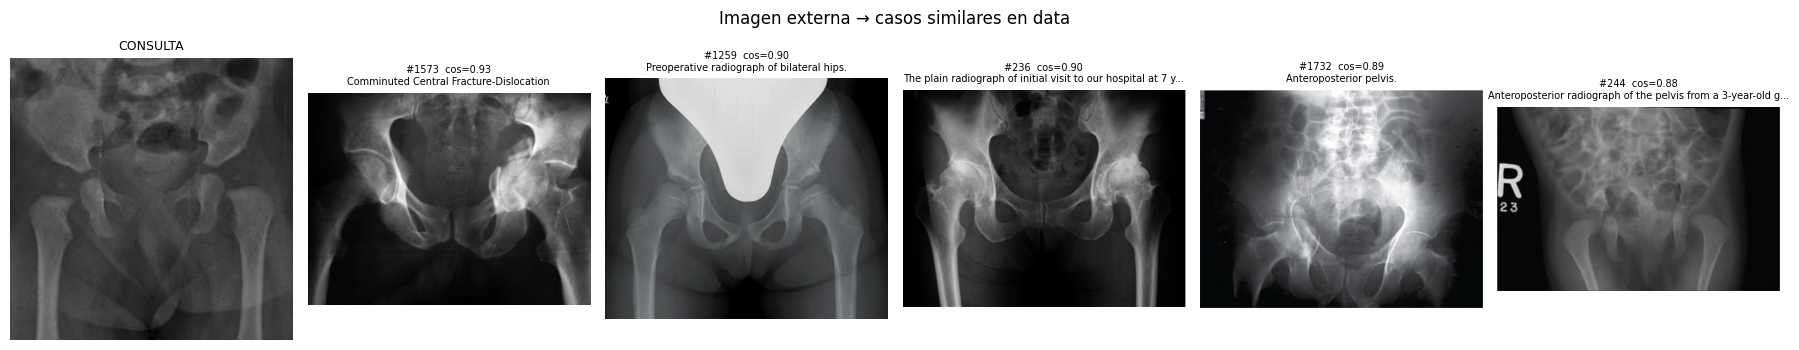

,index_data,similarity_cosine,caption,image_id,cui
0,1573,0.927249,Comminuted Central Fracture-Dislocation,ROCOv2_2023_train_001576,"[C1306645, C0030797, C1999039]"
1,1259,0.904955,Preoperative radiograph of bilateral hips.,ROCOv2_2023_train_001262,"[C1306645, C0030797, C1999039]"
2,236,0.902484,The plain radiograph of initial visit to our h...,ROCOv2_2023_train_000237,"[C1306645, C0030797, C1999039]"
3,1732,0.890134,Anteroposterior pelvis.,ROCOv2_2023_train_001737,"[C1306645, C0030797, C1999039]"
4,244,0.884945,Anteroposterior radiograph of the pelvis from ...,ROCOv2_2023_train_000245,"[C1306645, C0030797, C1999039]"


In [18]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

df_similares = search_external_image(
    image_path=image_path,
    encoder=encoder,
    index=index,
    k=5
)

df_similares

## 8. Búsqueda texto → imagen (solo BiomedCLIP)

Como BiomedCLIP alinea imagen y texto en el mismo espacio, podemos consultar con lenguaje natural.
Esta es la funcionalidad clave para un Teaching File: describes un hallazgo y recuperas casos.

In [ ]:
# === 8. Texto -> imagen ===
assert hasattr(encoder, "encode_text"), "Reconstruye con ENCODER_NAME='biomedclip' para búsqueda por texto."

text_queries = [
    "chest x-ray showing pleural effusion",
    "brain MRI with a tumor",
    "abdominal CT scan",
    "bone fracture on x-ray",
]
tfeat = encoder.encode_text(text_queries).numpy().astype(np.float32)
tfeat /= (np.linalg.norm(tfeat, axis=1, keepdims=True) + 1e-12)

t_i, t_s = index.search(tfeat, k=5)
for r, query in enumerate(text_queries):
    print("TEXTO:", query)
    show_neighbors(t_i[r], t_s[r], query_img=None, title=f"Texto -> Imagen: '{query}'")

## 9. Próximos pasos

- **Evaluación cuantitativa.** Usa los conceptos `cui` (modalidad/región) como etiquetas y mide *recuperación a k vecinos*: % de los k más cercanos que comparten concepto con la consulta. Compara `resnet50` vs `dinov2` vs `biomedclip` con la misma métrica.
- **Visualizar el espacio.** Proyecta los embeddings con UMAP y colorea por modalidad; un buen encoder médico agrupa RX / CT / MRI / US en clusters legibles.
- **Escalar la búsqueda.** A partir de cientos de miles de vectores, cambia `IndexFlatIP` por un índice aproximado de FAISS (IVF+PQ o HNSW). La interfaz de `SimilarityIndex` aísla ese cambio.
- **Encoders más fuertes.** MedImageInsight y MedGemma están pensados para recuperación imagen-imagen clínica; se conectan reescribiendo una subclase de `BaseEncoder`.
- **Nota.** Estos modelos están liberados para investigación, no validados para uso diagnóstico desplegado. Mantén el sistema encuadrado como herramienta educativa / de recuperación, no de decisión clínica.